# THỰC HÀNH 2.3: BAYES NGÂY THƠ (NAIVE BAYES) – PHÂN LOẠI SPAM


**Dữ liệu:** [Email Spam Detection](https://www.kaggle.com/code/zabihullah18/email-spam-detection) – file `spam.csv`.

**Mục tiêu:** vector hóa văn bản bằng Bag-of-Words, xây dựng `MultinomialNB`, đánh giá bằng accuracy / confusion matrix /
precision / recall / F1, so sánh các biến thể Naive Bayes và tối ưu tham số.

## 0. Ôn tập lý thuyết

**Định lý Bayes:** P(C|X) = P(X|C)·P(C) / P(X). Chọn lớp C có xác suất hậu nghiệm lớn nhất.

**Giả định "ngây thơ":** các đặc trưng độc lập có điều kiện khi biết lớp: P(X|C) = ∏ P(xᵢ|C). Giả định này hiếm khi đúng hoàn toàn
(ví dụ các từ trong câu có liên quan nhau) nhưng giúp mô hình đơn giản, huấn luyện rất nhanh, cần ít dữ liệu và thường vẫn hoạt động tốt, nhất là với văn bản.

| Biến thể | Dữ liệu phù hợp |
|---|---|
| **GaussianNB** | Đặc trưng số liên tục (giả định phân phối chuẩn) |
| **MultinomialNB** | Đếm tần suất (số lần xuất hiện của từ) – phân loại văn bản |
| **BernoulliNB** | Đặc trưng nhị phân (từ có/không xuất hiện) |
| **ComplementNB** | Biến thể của Multinomial, tốt hơn với dữ liệu mất cân bằng |

**Làm mịn Laplace (`alpha`)**: cộng thêm `alpha` vào số đếm để từ chưa từng xuất hiện trong lớp không làm xác suất bằng 0.

## 1. Nạp thư viện và dữ liệu

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import BernoulliNB, ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline

%matplotlib inline
warnings.filterwarnings("ignore")
OUT_DIR = Path("ket_qua/3_NB")
OUT_DIR.mkdir(exist_ok=True)

data = pd.read_csv("data/spam.csv", encoding="latin-1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 2. Xử lý dữ liệu

- Chỉ giữ 2 cột đầu (`v1`, `v2`); các cột `Unnamed: 2..4` gần như toàn NaN nên bỏ.
- Đổi tên thành `label`, `text`; loại dòng thiếu.
- Dùng `stratify=y` khi chia dữ liệu để giữ nguyên tỉ lệ ham/spam ở cả train và test.

In [2]:
data = data.iloc[:, :2].copy()
data.columns = ["label", "text"]
data = data.dropna()
print("Kích thước:", data.shape)
data["label"].value_counts()

Kích thước: (5572, 2)


label
ham     4825
spam     747
Name: count, dtype: int64

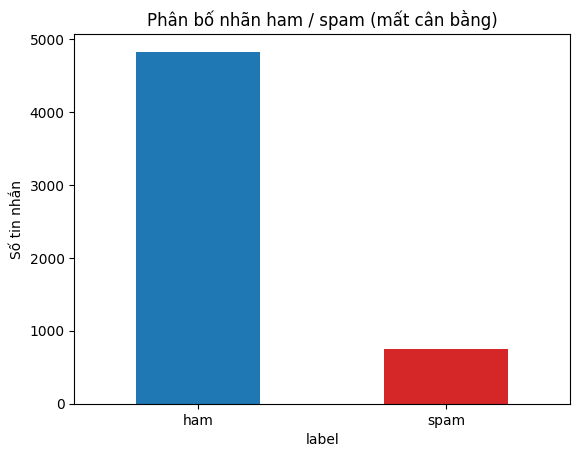

label
ham      71.0
spam    138.9
Name: do_dai, dtype: float64


In [3]:
data["label"].value_counts().plot.bar(rot=0, color=["tab:blue", "tab:red"])
plt.title("Phân bố nhãn ham / spam (mất cân bằng)")
plt.ylabel("Số tin nhắn")
plt.show()

data["do_dai"] = data["text"].str.len()
print(data.groupby("label")["do_dai"].mean().round(1))

In [4]:
X = data["text"]
y = data["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 4457 | Test: 1115


## 3. Vector hóa văn bản (Bag of Words)

`fit_transform` chỉ trên tập train; tập test chỉ `transform` để không rò rỉ thông tin.

In [5]:
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)
print("Kích thước từ vựng:", len(vectorizer.vocabulary_))
print("Ma trận train:", X_train_vectorized.shape)

Kích thước từ vựng: 7701
Ma trận train: (4457, 7701)


## 4. Xây dựng mô hình Multinomial Naive Bayes

In [6]:
classifier = MultinomialNB()
classifier.fit(X_train_vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## 5. Đánh giá hiệu quả mô hình

In [7]:
y_pred = classifier.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.98
Confusion Matrix:
[[961   5]
 [ 13 136]]
Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



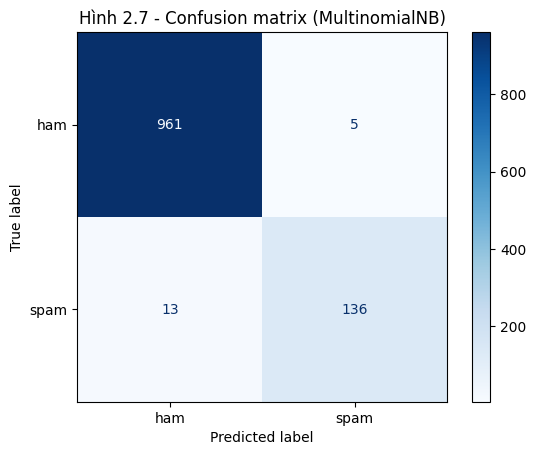

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Hình 2.7 - Confusion matrix (MultinomialNB)")
plt.savefig(OUT_DIR / "nb_confusion.png", bbox_inches="tight")
plt.show()

**Từ đặc trưng nhất của spam** (log xác suất của từ trong lớp spam trừ lớp ham):

In [9]:
fn = np.array(vectorizer.get_feature_names_out())
log_ratio = classifier.feature_log_prob_[1] - classifier.feature_log_prob_[0]
# classifier.classes_ = ['ham', 'spam'] nên chỉ số 1 là spam
top = pd.DataFrame({"từ": fn[np.argsort(log_ratio)[::-1][:15]],
                    "log_ratio": np.sort(log_ratio)[::-1][:15].round(2)})
top

,từ,log_ratio
0,claim,5.53
1,prize,5.20
2,150p,4.99
3,tone,4.83
4,18,4.72
5,cs,4.67
6,guaranteed,4.62
7,500,4.62
8,1000,4.50
9,uk,4.44


## 6. (Mở rộng) So sánh các biến thể Naive Bayes

In [10]:
rows = []
for name, model, binary in [("MultinomialNB", MultinomialNB(), False),
                            ("ComplementNB", ComplementNB(), False),
                            ("BernoulliNB", BernoulliNB(), True)]:
    vec = CountVectorizer(binary=binary)
    Xtr, Xte = vec.fit_transform(X_train), vec.transform(X_test)
    model.fit(Xtr, y_train)
    p = model.predict(Xte)
    rep = classification_report(y_test, p, output_dict=True)
    rows.append({"Mô hình": name,
                 "Accuracy": accuracy_score(y_test, p),
                 "Precision (spam)": rep["spam"]["precision"],
                 "Recall (spam)": rep["spam"]["recall"],
                 "F1 (spam)": rep["spam"]["f1-score"]})
so_sanh = pd.DataFrame(rows).round(4)
so_sanh.to_csv(OUT_DIR / "nb_so_sanh_bien_the.csv", index=False)
so_sanh

,Mô hình,Accuracy,Precision (spam),Recall (spam),F1 (spam)
0,MultinomialNB,0.9839,0.9645,0.9128,0.9379
1,ComplementNB,0.9821,0.9216,0.9463,0.9338
2,BernoulliNB,0.9758,1.0000,0.8188,0.9004


## 7. (Mở rộng) Tối ưu tham số bằng `GridSearchCV`

Dò `alpha`, kiểu vector hóa (đếm / TF-IDF), bỏ stop-words, n-gram.

In [11]:
pipe = Pipeline([("vec", CountVectorizer()), ("nb", MultinomialNB())])
grid = {
    "vec": [CountVectorizer(), TfidfVectorizer()],
    "vec__stop_words": [None, "english"],
    "vec__ngram_range": [(1, 1), (1, 2)],
    "nb__alpha": [0.01, 0.1, 0.5, 1.0],
}
gs = GridSearchCV(pipe, grid, cv=5, scoring="f1_macro", n_jobs=-1)
gs.fit(X_train, y_train)
print("Tham số tốt nhất:", gs.best_params_)
print(f"F1-macro CV: {gs.best_score_:.4f}")

p = gs.predict(X_test)
print(f"Accuracy test: {accuracy_score(y_test, p):.4f}")
print(classification_report(y_test, p))

Tham số tốt nhất: {'nb__alpha': 0.5, 'vec': CountVectorizer(), 'vec__ngram_range': (1, 2), 'vec__stop_words': 'english'}
F1-macro CV: 0.9756
Accuracy test: 0.9892
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.94      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



## 8. Thử dự đoán tin nhắn mới

In [12]:
mau = ["Congratulations! You won a free ticket. Call now to claim your prize",
       "Hey, are we still meeting for lunch tomorrow?"]
for m, kq in zip(mau, gs.predict(mau)):
    print(f"[{kq.upper():4s}] {m}")

[SPAM] Congratulations! You won a free ticket. Call now to claim your prize
[HAM ] Hey, are we still meeting for lunch tomorrow?
